<a href="https://colab.research.google.com/github/Richard-Palacio/Seminario-Ciencia-de-Datos/blob/main/KMeans_Guia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seminario de Ciencia de Datos
## Segmentación de Clientes con K-Means

Notebook estructurado con teoría, práctica, preguntas de evaluación y laboratorio guiado.

## Objetivos
- Comprender el aprendizaje no supervisado
- Aplicar K-Means
- Interpretar clusters y centroides
- Analizar resultados desde negocio

In [2]:
# ===============================
# 1. IMPORTAR LIBRERÍAS
# ===============================

# COMPLETAR POR EL ESTUDIANTE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print('Librerías importadas correctamente')

Librerías importadas correctamente


## Carga de Datos
Cargar el dataset de clientes.

In [3]:
# COMPLETAR
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [6]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Exploracion del Dataset

In [7]:
print("="*70)
print("INFORMACIÓN DEL DATASET")
print("="*70)

print(f"\n📊 Dimensiones: {df.shape[0]} clientes × {df.shape[1]} variables")
print(f"\n🔍 Primeras 10 filas:")
print(df.head(10))

print(f"\n📈 Información general:")
print(df.info())

print(f"\n📊 Estadísticas descriptivas:")
print(df.describe().round(2))

print(f"\n🔎 Valores faltantes:")
print(df.isnull().sum())

INFORMACIÓN DEL DATASET

📊 Dimensiones: 200 clientes × 5 variables

🔍 Primeras 10 filas:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72

📈 Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #

## Preparar Datos para K-Means

In [16]:
# Seleccionar características numéricas para clustering
# Excluimos CustomerID y Genre (no son numéricas para clustering)

caracteristicas = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

print("📊 PREPARACIÓN DE DATOS")
print("="*70)
print(f"\nCaracterísticas seleccionadas para clustering:")
for i, feat in enumerate(caracteristicas, 1):
    print(f"  {i}. {feat}")

# Extraer las características
X = df[caracteristicas].copy()

# Normalizar (StandardScaler)
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

print(f"\n✅ Datos escalados correctamente")
print(f"   Forma original: {X.shape}")
print(f"   Forma escalada: {X_escalado.shape}")
print(f"\n   Rango original:")
print(f"   - Age: {X['Age'].min()}-{X['Age'].max()} años")
print(f"   - Annual Income: {X['Annual Income (k$)'].min()}-{X['Annual Income (k$)'].max()} k$")
print(f"   - Spending Score: {X['Spending Score (1-100)'].min()}-{X['Spending Score (1-100)'].max()}")
print(f"\n   Después de escalado (StandardScaler):")
print(f"   - Media: {X_escalado.mean(axis=0).round(4)}")
print(f"   - Desv. Est.: {X_escalado.std(axis=0).round(4)}")

📊 PREPARACIÓN DE DATOS

Características seleccionadas para clustering:
  1. Age
  2. Annual Income (k$)
  3. Spending Score (1-100)

✅ Datos escalados correctamente
   Forma original: (200, 3)
   Forma escalada: (200, 3)

   Rango original:
   - Age: 18-70 años
   - Annual Income: 15-137 k$
   - Spending Score: 1-99

   Después de escalado (StandardScaler):
   - Media: [-0. -0. -0.]
   - Desv. Est.: [1. 1. 1.]


## Selección de Variables
Usar: Annual Income y Spending Score.

In [17]:
# COMPLETAR
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
print('Variables seleccionadas:')
X.head()

Variables seleccionadas:


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Método del Codo

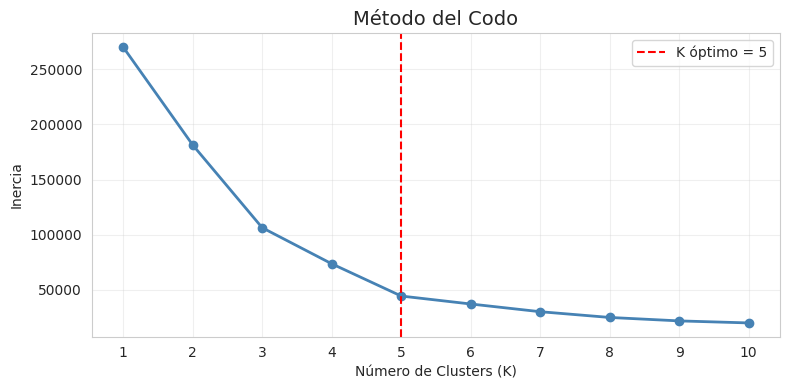

In [18]:
# COMPLETAR
inercia = []
for k in range(1, 11):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X)
    inercia.append(modelo.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inercia, marker='o', color='steelblue', linewidth=2)
plt.title('Método del Codo', fontsize=14)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.xticks(range(1, 11))
plt.axvline(x=5, color='red', linestyle='--', label='K óptimo = 5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Entrenamiento del Modelo

In [19]:
# COMPLETAR

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X)
df['Cluster'] = kmeans.labels_

print('Modelo entrenado ✓')
print('\nCentroides de cada cluster:')
centroides = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Ingreso Anual (k$)', 'Puntuación de Gasto']
)
centroides.index.name = 'Cluster'
print(centroides.round(1))

Modelo entrenado ✓

Centroides de cada cluster:
         Ingreso Anual (k$)  Puntuación de Gasto
Cluster                                         
0                      55.3                 49.5
1                      86.5                 82.1
2                      25.7                 79.4
3                      88.2                 17.1
4                      26.3                 20.9


## Visualización

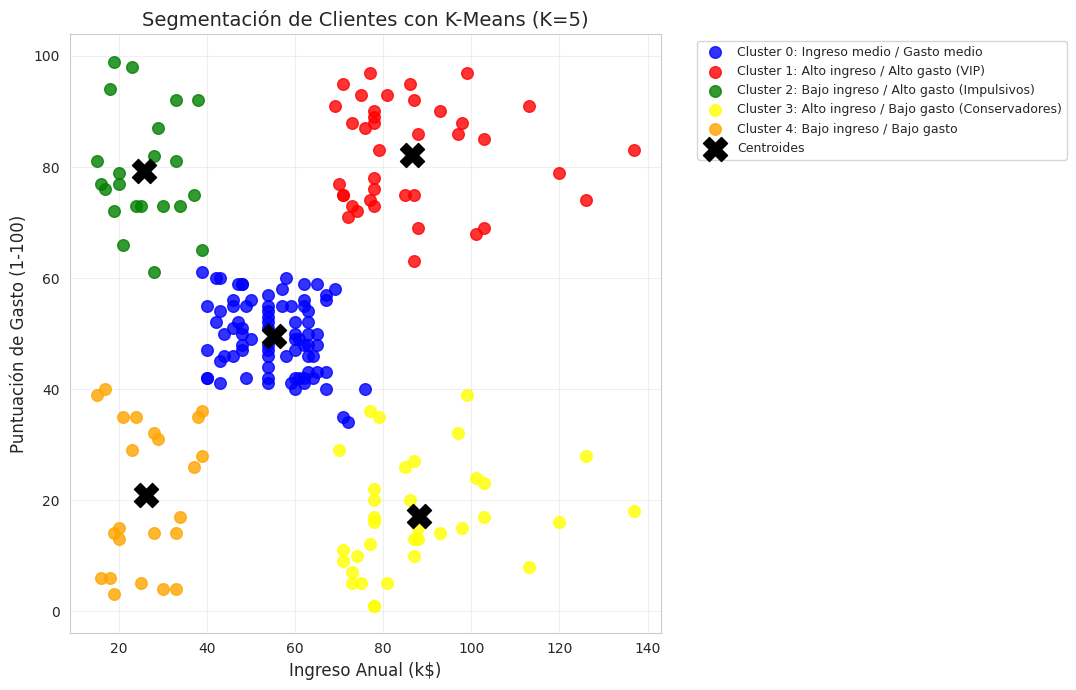

In [20]:
# COMPLETAR VISUALIZACIÓN
colores = ['blue', 'red', 'green', 'yellow', 'orange']
nombres = [
    'Cluster 0: Ingreso medio / Gasto medio',
    'Cluster 1: Alto ingreso / Alto gasto (VIP)',
    'Cluster 2: Bajo ingreso / Alto gasto (Impulsivos)',
    'Cluster 3: Alto ingreso / Bajo gasto (Conservadores)',
    'Cluster 4: Bajo ingreso / Bajo gasto'
]

plt.figure(figsize=(11, 7))
for i in range(5):
    mask = df['Cluster'] == i
    plt.scatter(
        X[mask]['Annual Income (k$)'],
        X[mask]['Spending Score (1-100)'],
        c=colores[i], label=nombres[i], s=70, alpha=0.8
    )

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300, c='black', marker='X', zorder=5, label='Centroides'
)

plt.xlabel('Ingreso Anual (k$)', fontsize=12)
plt.ylabel('Puntuación de Gasto (1-100)', fontsize=12)
plt.title('Segmentación de Clientes con K-Means (K=5)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Preguntas de Evaluación
1. ¿Por qué es aprendizaje no supervisado?
2. ¿Qué es un centroide?
3. ¿Qué sucede si K es muy alto?
4. ¿Para qué sirve el método del codo?
5. Interprete los clusters desde negocio.

# Respuestas

---

### 1. ¿Por qué es aprendizaje no supervisado?
Porque el algoritmo trabaja con datos que **no tienen etiquetas predefinidas** ni una variable objetivo a predecir. K-Means no intenta adivinar una respuesta "correcta", sino que analiza la estructura interna de los datos para descubrir patrones y agrupaciones naturales (en este caso, segmentos de clientes) basándose únicamente en la similitud de sus características.

---

### 2. ¿Qué es un centroide?
Un centroide es el **centro geométrico** de un clúster. Matemáticamente, representa el vector con el promedio (media) de todas las características de los puntos asignados a ese grupo. Funciona como el "representante" o el perfil prototipo de ese segmento, y el algoritmo lo recalcula iterativamente hasta que el modelo se obtiene la estabilidad.

---

### 3. ¿Qué sucede si $K$ es muy alto?
Si el número de clústeres ($K$) es excesivamente alto, el modelo sufre de los siguientes problemas:
* **Sobreajuste (*Overfitting*):** Los grupos se vuelven tan pequeños y específicos (incluso llegando a un solo dato por grupo) que el modelo pierde la capacidad de generalizar con nuevos clientes.
* **Pérdida de valor de negocio:** Las diferencias entre clústeres se vuelven milimétricas, haciendo imposible e ineficiente diseñar estrategias de marketing diferenciadas para cada uno.
* **Costo computacional:** Aumenta innecesariamente el tiempo de procesamiento y la complejidad del algoritmo al tener que calcular distancias contra demasiados puntos centrales.

---

### 4. ¿Para qué sirve el método del codo?
Es una técnica visual utilizada para **determinar el número óptimo de clústeres ($K$)**. Consiste en graficar la inercia (la suma de las distancias al cuadrado de cada punto a su centroide) en función de $K$.

A medida que aumentamos los clústeres, la inercia siempre baja. El "codo" es el punto de inflexión exacto donde la velocidad de esa caída disminuye drásticamente, indicando que añadir más grupos ya no aporta información lo suficientemente significativa como para justificar la complejidad.

---

### 5. Interpretación de los Clusters desde la Perspectiva de Negocio ($K = 5$)

A partir del análisis de las variables *Ingreso Anual* y *Puntuación de Gasto* de nuestro modelo, se identifican los siguientes 5 perfiles estratégicos de clientes:

| Clúster / Color | Perfil de Negocio | Descripción del Comportamiento | Estrategia de Marketing Recomendada |
| :--- | :--- | :--- | :--- |
| **Cluster 0** <br> 🔵 Azul | **Clientes Promedio** | Ingreso medio y gasto medio. Son el núcleo estable del centro comercial. | Campañas de fidelización estándar y ofertas de temporada para mantener su flujo constante de visitas. |
| **Cluster 1** <br> 🔴 Rojo | **Clientes VIP / Premium** | Alto ingreso y alto nivel de gasto. Son los clientes más rentables del negocio. | Trato preferencial, acceso anticipado a colecciones, invitaciones a eventos exclusivos y programas de puntos premium. |
| **Cluster 2** <br> 🟢 Verde | **Clientes Impulsivos** | Bajo ingreso pero alto nivel de gasto. Suelen ser compradores emocionales o público joven. | Promociones *flash*, descuentos atractivos por volumen de compra y opciones de financiamiento accesibles. |
| **Cluster 3** <br> 🟡 Amarillo | **Clientes Conservadores** | Alto ingreso pero bajo nivel de gasto. Tienen capital pero son muy cautelosos. | Campañas enfocadas en la calidad, durabilidad y valor real del producto. Invitaciones a servicios personalizados. |
| **Cluster 4** <br> 🟠 Naranja | **Clientes Sensibles al Precio** | Bajo ingreso y bajo nivel de gasto. Visitan poco o compran lo estrictamente necesario. | Cupones de descuento masivos, promociones tipo 2x1 y visibilidad de líneas económicas o de salida de inventario (*outlet*). |

> **Conclusión de negocio:** Esta segmentación permite sustituir una estrategia de marketing masiva y genérica por esfuerzos dirigidos, maximizando el retorno de inversión (ROI) al comunicarse con cada cliente según sus necesidades y posibilidades reales.

## Conclusión
K-Means permite segmentar clientes y apoyar decisiones estratégicas basadas en datos.